# Hierarchical dynamic teams pattern

In real-world data science and analytics organizations, not every project requires the same team composition. A simple exploratory analysis might need only a data analyst, while a complex ML pipeline project requires data engineers, data scientists, DBAs, and visualization experts working together. Static team structures waste resources and slow down simple tasks, while rigid workflows cannot adapt to changing project requirements. The hierarchical dynamic teams pattern solves this by enabling autonomous team composition:
- **Dynamic team selection:** A supervisor agent analyzes the task and decides which specialists to include.
- **Adaptive resource allocation:** Simple tasks get minimal teams; complex projects get full teams.
- **Autonomous worker agents:** Each specialist runs a ReAct loop with domain-specific tools.
- **Intelligent coordination:** The coordinator integrates outputs based on who actually participated.

This pattern is particularly valuable for:
- Data science platforms serving diverse project types (ETL, ML, dashboards, ad-hoc analysis).
- Organizations optimizing resource utilization across varying workloads.
- Systems where task complexity varies significantly and cannot be predetermined.
- Projects requiring different skill combinations for different phases.

In this notebook, we will implement a dynamic data science team system:

**Worker Agents (5 specialists):** Each runs a ReAct loop (Reason → Act → Observe → repeat) with domain-specific tools:
- Data Engineer (ETL pipelines, data quality).
- Data Scientist (ML models, statistical analysis).
- Data Analyst (business intelligence, metrics).
- Visualization Expert (charts, dashboards).
- DBA (database optimization, schema design).

**Supervisor Agent:** Analyzes each task and autonomously selects which specialists are needed:
- Reasons about task requirements.
- Determines optimal team composition.
- Delegates to selected workers only.

**Coordinator Agent:** Orchestrates the entire system:
- Invokes the supervisor to get team selection.
- Runs only the selected worker agents.
- Integrates outputs from participating workers.
- Produces final deliverable.

This demonstrates how dynamic team composition adapts to task complexity while maintaining autonomous agent behavior at every level.

In [1]:
import os
import json
from typing import TypedDict, Sequence, Annotated, List, Dict, Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import HTML, display
import base64

### Initialize the language model

We use a consistent model across all agents for reliable coordination and dynamic team selection.

In [2]:
# Initialize the OpenAI language model
# Using temperature=0 for consistent, reliable team selection and task execution
llm = ChatOpenAI(model="gpt-4o-mini-2024-07-18", api_key=os.getenv("OPENAI_API_KEY", "").strip(), temperature=0)

## Part 1: Define domain-specific tools for each worker type
Autonomous agents must have tools they can invoke based on their own reasoning. These tools represent specialized capabilities for each role. Workers will autonomously decide when and which tools to call during their ReAct loops. Each worker type gets tools that match their domain expertise:
- **Data Engineer:** Pipeline design, data quality validation
- **Data Scientist:** Model selection, feature engineering
- **Data Analyst:** Metric calculation, business analysis
- **Visualization Expert:** Chart recommendations, dashboard design
- **DBA:** Query optimization, schema design

In [3]:
# ==================== Data Engineer Tools ====================

@tool
def design_etl_pipeline(source: str, destination: str, requirements: str) -> str:
    """Design an ETL pipeline architecture based on source, destination, and requirements."""
    patterns = {
        "batch": "Design: Use Apache Airflow for orchestration. Extract with scheduled DAGs (daily/hourly). Stage data in S3/GCS. Transform using Spark/dbt for large volumes. Load with COPY/BULK INSERT for efficiency. Include data validation checkpoints. Implement idempotent operations for retry safety.",
        "streaming": "Design: Use Apache Kafka for event streaming. Extract with change data capture (Debezium). Transform in-flight with Kafka Streams/Flink. Load to sink connectors (JDBC, Elasticsearch). Implement exactly-once semantics. Add dead letter queues for failed messages.",
        "real-time": "Design: Use event-driven architecture. Extract with webhooks/message queues. Transform with serverless functions (Lambda/Cloud Functions). Load with streaming inserts. Implement circuit breakers. Add monitoring for latency SLAs.",
    }
    for key, design in patterns.items():
        if key in requirements.lower():
            return f"ETL Pipeline Design ({source} → {destination}):\\n{design}"
    return f"ETL Pipeline Design ({source} → {destination}): Use batch processing with Airflow. Extract with connectors, transform with SQL/Python, load with bulk operations. Implement data quality checks and monitoring."

@tool
def validate_data_quality(dataset: str, quality_requirements: str) -> str:
    """Validate data quality rules and return recommendations."""
    checks = {
        "completeness": "Check: Verify no critical columns have NULL values. Measure completeness ratio (non-null / total rows). Set threshold at 95% for critical fields. Implement alerts for drops below threshold.",
        "accuracy": "Check: Validate against business rules (e.g., dates in valid range, amounts > 0). Cross-reference with source systems. Use statistical outlier detection (z-score > 3). Implement reconciliation reports.",
        "consistency": "Check: Verify referential integrity across tables. Ensure consistent data types and formats. Validate aggregations match detail records. Check for duplicate records using composite keys.",
        "timeliness": "Check: Monitor data freshness (time since last update). Set SLAs for data availability. Alert on stale data. Track end-to-end pipeline latency.",
    }
    recommendations = []
    for key, check in checks.items():
        if key in quality_requirements.lower():
            recommendations.append(check)
    if not recommendations:
        recommendations = list(checks.values())
    return f"Data Quality Validation for '{dataset}':\\n" + "\\n".join(recommendations)

# ==================== Data Scientist Tools ====================

@tool
def recommend_ml_model(problem_type: str, data_characteristics: str) -> str:
    """Recommend ML models based on problem type and data characteristics."""
    recommendations = {
        "classification": "Models: (1) Logistic Regression - fast baseline, interpretable. (2) Random Forest - handles non-linear relationships, feature importance. (3) XGBoost - high performance, handles missing values. (4) Neural Network - complex patterns, large datasets. Start with Random Forest for balanced performance/interpretability.",
        "regression": "Models: (1) Linear Regression - fast baseline, interpretable. (2) Ridge/Lasso - regularization for high-dimensional data. (3) Gradient Boosting - captures non-linear relationships. (4) Neural Network - complex patterns. Start with Ridge for interpretability.",
        "clustering": "Models: (1) K-Means - fast, works with spherical clusters. (2) DBSCAN - handles arbitrary shapes, detects outliers. (3) Hierarchical - no need to specify K, produces dendrogram. (4) Gaussian Mixture - probabilistic, soft clustering. Start with K-Means for simplicity.",
        "time series": "Models: (1) ARIMA - linear patterns, seasonal decomposition. (2) Prophet - handles holidays, missing data. (3) LSTM - complex temporal dependencies. (4) XGBoost - feature engineering from lags. Start with Prophet for robustness.",
    }
    for key, rec in recommendations.items():
        if key in problem_type.lower():
            return f"ML Model Recommendations for {problem_type}:\\n{rec}\\n\\nData considerations: {data_characteristics}"
    return f"ML Model Recommendations: Analyze problem type further. Consider ensemble methods for robust performance. Evaluate multiple models with cross-validation."

@tool
def suggest_feature_engineering(features: str, target: str) -> str:
    """Suggest feature engineering techniques for given features and target."""
    techniques = [
        "Numerical features: (1) Scaling - StandardScaler for tree models, MinMaxScaler for neural networks. (2) Binning - discretize continuous values for non-linear effects. (3) Log transform - handle skewed distributions. (4) Polynomial features - capture interactions.",
        "Categorical features: (1) One-hot encoding - for low cardinality (<10 categories). (2) Target encoding - for high cardinality, use regularization. (3) Frequency encoding - capture category prevalence. (4) Embedding - for very high cardinality.",
        "Date/Time features: (1) Extract - year, month, day, day_of_week, hour. (2) Cyclical encoding - sin/cos transform for circular features (hour, month). (3) Time since - calculate days/hours since reference event. (4) Lag features - for time series.",
        "Text features: (1) TF-IDF - capture term importance. (2) Word embeddings - Word2Vec, GloVe for semantic meaning. (3) Length features - character/word count. (4) Sentiment scores - for text with opinions.",
        "Feature interactions: (1) Cross features - multiply related features. (2) Aggregations - group-by statistics. (3) Ratios - divide related features. (4) Domain-specific - create features based on business knowledge.",
    ]
    return f"Feature Engineering for predicting '{target}':\\n\\n" + "\\n\\n".join(techniques)

# ==================== Data Analyst Tools ====================

@tool
def calculate_business_metrics(metric_name: str, dimensions: str) -> str:
    """Calculate business metrics with proper formulas and aggregation logic."""
    metrics = {
        "customer lifetime value": "Metric: CLV = (Average Purchase Value × Purchase Frequency) × Average Customer Lifespan. Dimensions: Segment by customer cohort, acquisition channel, product category. Time period: Calculate monthly, track trends. Benchmarks: Compare to customer acquisition cost (CAC). Target: CLV/CAC ratio > 3.",
        "churn rate": "Metric: Churn Rate = (Customers Lost / Total Customers at Start) × 100. Dimensions: Segment by tenure, product tier, engagement level. Time period: Calculate monthly, compare cohorts. Leading indicators: Track engagement decline, support tickets, payment failures. Target: <5% monthly for SaaS.",
        "conversion rate": "Metric: Conversion Rate = (Conversions / Total Visitors) × 100. Dimensions: Segment by traffic source, device type, user segment. Funnel analysis: Track drop-off at each stage. A/B testing: Compare variants statistically. Target: Depends on industry, track trends.",
        "revenue per user": "Metric: ARPU = Total Revenue / Number of Users. Dimensions: Segment by user type, geography, product. Time period: Calculate monthly, quarterly. Related metrics: Track alongside user growth, expansion revenue. Target: Positive trend month-over-month.",
    }
    for key, formula in metrics.items():
        if key in metric_name.lower():
            return f"Business Metric: {metric_name}\\n{formula}\\n\\nDimensions to analyze: {dimensions}"
    return f"Business Metric: {metric_name}\\nDefine clear calculation logic. Identify relevant dimensions: {dimensions}. Choose appropriate aggregation level (daily/weekly/monthly). Ensure data quality and completeness."

@tool
def analyze_business_question(question: str, available_data: str) -> str:
    """Analyze a business question and provide analytical approach."""
    approach = f"""Analytical Approach for: '{question}'

1. Clarify the question:
   - Define success metrics (what does \"success\" look like numerically?)
   - Identify stakeholders and their decisions
   - Determine time frame and granularity

2. Data assessment:
   - Available data: {available_data}
   - Identify gaps in data coverage
   - Assess data quality (completeness, accuracy, timeliness)

3. Analytical method:
   - Descriptive: What happened? (aggregations, trends)
   - Diagnostic: Why did it happen? (segmentation, correlation)
   - Predictive: What will happen? (forecasting, modeling)
   - Prescriptive: What should we do? (optimization, simulation)

4. Segmentation:
   - Identify relevant dimensions (geography, product, customer segment)
   - Look for patterns within segments
   - Compare segments to identify drivers

5. Validation:
   - Sanity checks (do numbers make business sense?)
   - Cross-reference with other data sources
   - Statistical significance testing

6. Actionable insights:
   - Translate findings to business recommendations
   - Quantify potential impact
   - Identify next steps and monitoring plan
"""
    return approach

# ==================== Visualization Expert Tools ====================

@tool
def recommend_chart_type(data_type: str, purpose: str) -> str:
    """Recommend appropriate chart types based on data and purpose."""
    recommendations = {
        "comparison": "Charts: (1) Bar chart - compare categories, easy to read exact values. (2) Grouped bar - compare multiple metrics across categories. (3) Bullet chart - compare actual vs target. Best practices: Sort bars by value, start axis at zero, limit to <10 categories.",
        "trend": "Charts: (1) Line chart - show changes over time, multiple series. (2) Area chart - emphasize magnitude of change, show cumulative. (3) Slope chart - compare two time points. Best practices: Use consistent time intervals, highlight important events, avoid too many lines (max 5).",
        "distribution": "Charts: (1) Histogram - show frequency distribution, identify outliers. (2) Box plot - show quartiles and outliers. (3) Violin plot - show distribution shape. Best practices: Choose appropriate bin width, show sample size, mark mean/median.",
        "relationship": "Charts: (1) Scatter plot - show correlation between two variables. (2) Bubble chart - add third dimension with size. (3) Heatmap - show correlation matrix. Best practices: Add trend line, label outliers, use color for categorical dimension.",
        "composition": "Charts: (1) Stacked bar - show part-to-whole over categories. (2) Pie chart - show simple proportions (max 5 slices). (3) Treemap - show hierarchical composition. Best practices: Order by size, use distinct colors, show percentages.",
    }
    for key, rec in recommendations.items():
        if key in purpose.lower():
            return f"Chart Recommendations for {purpose}:\\n{rec}\\n\\nData type: {data_type}"
    return f"Chart Recommendations: Consider the relationship between variables and the story you want to tell. Choose clarity over complexity. Test with actual data."

@tool
def design_dashboard_layout(metrics: str, audience: str) -> str:
    """Design dashboard layout based on metrics and audience."""
    design = f"""Dashboard Design for {audience}:

Metrics to display: {metrics}

Layout principles:
1. Information hierarchy:
   - Top: Most critical KPIs (large, prominent)
   - Middle: Supporting metrics and trends
   - Bottom: Detailed breakdowns and drill-downs

2. Visual flow:
   - F-pattern or Z-pattern reading flow
   - Group related metrics together
   - Use white space to separate sections

3. Executive dashboard:
   - 6-8 KPI cards at top (current value, trend, vs target)
   - 2-3 key trend charts (revenue, users, etc.)
   - 1-2 comparison charts (segments, channels)
   - Minimal clutter, high-level insights

4. Operational dashboard:
   - Real-time metrics with refresh indicators
   - Status indicators (red/yellow/green)
   - Alerts and anomalies highlighted
   - Drill-down capability to details

5. Analytical dashboard:
   - Interactive filters (date, segment, product)
   - Multiple visualization types
   - Comparison tools (time periods, segments)
   - Export capability for further analysis

6. Best practices:
   - Limit to single screen (no scrolling for key metrics)
   - Use consistent color scheme (brand colors)
   - Add context (targets, benchmarks, prior period)
   - Include data freshness timestamp
   - Optimize load time (<3 seconds)
"""
    return design

# ==================== DBA Tools ====================

@tool
def optimize_query_performance(query_pattern: str, performance_issue: str) -> str:
    """Provide query optimization recommendations based on pattern and issue."""
    optimizations = {
        "slow joins": "Optimization: (1) Add indexes on join columns (foreign keys). (2) Use EXPLAIN to check join order - put selective tables first. (3) Consider denormalization for frequently joined tables. (4) Use covering indexes to avoid table lookups. (5) For large tables, partition on join key. (6) Rewrite subqueries as joins where possible.",
        "full table scan": "Optimization: (1) Add index on WHERE clause columns. (2) Use composite indexes for multi-column filters. (3) Update table statistics for query planner. (4) Partition large tables. (5) Use LIMIT if you don't need all rows. (6) Consider materialized views for complex aggregations.",
        "high memory": "Optimization: (1) Reduce result set size with proper filtering. (2) Use streaming for large result sets. (3) Increase work_mem/sort_buffer_size. (4) Break complex queries into steps with temp tables. (5) Use indexes to avoid sorting. (6) Optimize GROUP BY with pre-aggregated tables.",
        "slow aggregation": "Optimization: (1) Create materialized views for common aggregations. (2) Use pre-aggregated rollup tables. (3) Partition large fact tables by date. (4) Index columns used in GROUP BY. (5) Use column-oriented storage for analytics. (6) Consider approximate algorithms (HyperLogLog) for distinct counts.",
    }
    for key, opt in optimizations.items():
        if key in performance_issue.lower():
            return f"Query Optimization for '{performance_issue}':\\n{opt}\\n\\nQuery pattern: {query_pattern}"
    return f"Query Optimization: Run EXPLAIN ANALYZE to identify bottlenecks. Check for missing indexes, outdated statistics, or inefficient query structure. Monitor query plans after changes."

@tool
def design_database_schema(entities: str, requirements: str) -> str:
    """Design database schema based on entities and requirements."""
    design = f"""Database Schema Design:

Entities: {entities}
Requirements: {requirements}

Design principles:

1. Normalization:
   - 3NF for transactional systems (reduce redundancy)
   - Denormalize for analytical systems (optimize reads)
   - Document intentional denormalization

2. Primary keys:
   - Use UUIDs for distributed systems
   - Use auto-increment integers for single-database systems
   - Use natural keys only if truly immutable and unique

3. Foreign keys:
   - Define all relationships explicitly
   - Add indexes on foreign key columns
   - Choose appropriate ON DELETE/UPDATE actions
   - Consider soft deletes (deleted_at) for audit trails

4. Data types:
   - Use smallest appropriate type (storage and performance)
   - VARCHAR(255) for variable text, TEXT for long content
   - DECIMAL for money (never FLOAT)
   - TIMESTAMP for dates (store in UTC)
   - JSON for flexible schema (when appropriate)

5. Constraints:
   - NOT NULL for required fields
   - UNIQUE for business uniqueness constraints
   - CHECK constraints for valid value ranges
   - Default values where appropriate

6. Indexes:
   - Index foreign keys (for joins)
   - Index columns in WHERE clauses
   - Composite indexes for multi-column filters
   - Avoid over-indexing (write performance cost)

7. Standard columns (all tables):
   - id (primary key)
   - created_at (timestamp, NOT NULL, default NOW())
   - updated_at (timestamp, NOT NULL, default NOW(), on update NOW())
   - created_by (user reference, for audit)
   - updated_by (user reference, for audit)

8. Partitioning strategy (for large tables):
   - Partition by date for time-series data
   - Partition by range for evenly distributed data
   - Partition by list for categorical data
   - Consider retention policy (archive old partitions)
"""
    return design

# Collect tools for each worker type
data_engineer_tools = [design_etl_pipeline, validate_data_quality]
data_scientist_tools = [recommend_ml_model, suggest_feature_engineering]
data_analyst_tools = [calculate_business_metrics, analyze_business_question]
visualization_tools = [recommend_chart_type, design_dashboard_layout]
dba_tools = [optimize_query_performance, design_database_schema]

# Bind tools to model variants for each worker type
llm_data_engineer = llm.bind_tools(data_engineer_tools)
llm_data_scientist = llm.bind_tools(data_scientist_tools)
llm_data_analyst = llm.bind_tools(data_analyst_tools)
llm_visualization = llm.bind_tools(visualization_tools)
llm_dba = llm.bind_tools(dba_tools)

print("✓ Domain-specific tools defined for 5 worker types")

✓ Domain-specific tools defined for 5 worker types


## Part 2: Build autonomous worker agents with ReAct loops
Worker agents are autonomous specialists who perform implementation work through iterative reasoning. Each agent reasons about what to do, takes an action (tool call or produces output), observes the result, then reasons again. This loop continues until the agent decides its work is done.

### Autonomous reasoning loop structure
Every worker graph follows the same ReAct loop structure:
```
START → reason → [tool call?] → act → reason → [done?] → END
                     ↑_________________________|
```
The `reason` node calls the LLM. If the response contains tool calls, the agent routes to `act` to execute them, then loops back to `reason` with the observations. When the LLM produces a final response with no tool calls, the agent exits.

We implement all 5 worker types, each with their domain-specific tools and expertise.

In [4]:
# Shared state structure for all worker agents
class WorkerAgentState(TypedDict):
    """State for autonomous worker agents."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    task: str       # The task assigned by the coordinator
    output: str     # The final deliverable produced by this agent
    tool_calls_count: int

def should_continue_or_end(state: WorkerAgentState) -> Literal["act", "end"]:
    """Routing function: continue acting if there are tool calls, otherwise end."""
    last_message = state["messages"][-1]
    tool_calls_count = state.get("tool_calls_count", 0)

    # Stop after 5 tool calls to prevent infinite loops
    if tool_calls_count >= 5:
        return "end"
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "act"
    return "end"

def extract_output(state: WorkerAgentState) -> WorkerAgentState:
    """Extract the final output from the agent's last message."""
    last_message = state["messages"][-1]
    return {"output": last_message.content}

# --- Data Engineer Agent ---

def data_engineer_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Data Engineer reasons about ETL pipelines and data quality."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Data Engineer agent.

        Your responsibility: Design ETL pipelines and ensure data quality for the task assigned to you.
        You have access to tools to design pipelines and validate data quality requirements.
        Use them when you need specific architectural patterns or quality checks.

        Work through the task step by step. When your pipeline design is complete and
        data quality measures are defined, produce your final deliverable.
        """
    )
    response = llm_data_engineer.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

data_engineer_graph = StateGraph(WorkerAgentState)
data_engineer_graph.add_node("reason", data_engineer_reason)
data_engineer_graph.add_node("act", ToolNode(data_engineer_tools))
data_engineer_graph.add_node("extract", extract_output)
data_engineer_graph.add_edge(START, "reason")
data_engineer_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
data_engineer_graph.add_edge("act", "reason")
data_engineer_graph.add_edge("extract", END)
data_engineer_agent = data_engineer_graph.compile()

# --- Data Scientist Agent ---

def data_scientist_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Data Scientist reasons about ML models and feature engineering."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Data Scientist agent.

        Your responsibility: Design machine learning solutions and feature engineering for the task assigned to you.
        You have access to tools to recommend ML models and suggest feature engineering techniques.
        Use them to ensure your approach is scientifically sound and practical.

        Work through the task step by step. When your ML solution design is complete,
        produce your final deliverable.
        """
    )
    response = llm_data_scientist.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

data_scientist_graph = StateGraph(WorkerAgentState)
data_scientist_graph.add_node("reason", data_scientist_reason)
data_scientist_graph.add_node("act", ToolNode(data_scientist_tools))
data_scientist_graph.add_node("extract", extract_output)
data_scientist_graph.add_edge(START, "reason")
data_scientist_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
data_scientist_graph.add_edge("act", "reason")
data_scientist_graph.add_edge("extract", END)
data_scientist_agent = data_scientist_graph.compile()

# --- Data Analyst Agent ---

def data_analyst_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Data Analyst reasons about business metrics and analysis."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Data Analyst agent.

        Your responsibility: Define business metrics and analytical approaches for the task assigned to you.
        You have access to tools to calculate business metrics and analyze business questions.
        Use them to ground your analysis in proven methodologies.

        Work through the task step by step. When your analytical approach is complete,
        produce your final deliverable.
        """
    )
    response = llm_data_analyst.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

data_analyst_graph = StateGraph(WorkerAgentState)
data_analyst_graph.add_node("reason", data_analyst_reason)
data_analyst_graph.add_node("act", ToolNode(data_analyst_tools))
data_analyst_graph.add_node("extract", extract_output)
data_analyst_graph.add_edge(START, "reason")
data_analyst_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
data_analyst_graph.add_edge("act", "reason")
data_analyst_graph.add_edge("extract", END)
data_analyst_agent = data_analyst_graph.compile()

# --- Visualization Expert Agent ---

def visualization_expert_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Visualization Expert reasons about charts and dashboards."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Visualization Expert agent.

        Your responsibility: Design visualizations and dashboards for the task assigned to you.
        You have access to tools to recommend chart types and design dashboard layouts.
        Use them to ensure your visualizations follow best practices and are effective.

        Work through the task step by step. When your visualization design is complete,
        produce your final deliverable.
        """
    )
    response = llm_visualization.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

visualization_expert_graph = StateGraph(WorkerAgentState)
visualization_expert_graph.add_node("reason", visualization_expert_reason)
visualization_expert_graph.add_node("act", ToolNode(visualization_tools))
visualization_expert_graph.add_node("extract", extract_output)
visualization_expert_graph.add_edge(START, "reason")
visualization_expert_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
visualization_expert_graph.add_edge("act", "reason")
visualization_expert_graph.add_edge("extract", END)
visualization_expert_agent = visualization_expert_graph.compile()

# --- DBA Agent ---

def dba_reason(state: WorkerAgentState) -> WorkerAgentState:
    """DBA reasons about database optimization and schema design."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Database Administrator (DBA) agent.

        Your responsibility: Optimize database performance and design schemas for the task assigned to you.
        You have access to tools to optimize queries and design database schemas.
        Use them to ensure your database solutions are efficient and well-structured.

        Work through the task step by step. When your database solution is complete,
        produce your final deliverable.
        """
    )
    response = llm_dba.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

dba_graph = StateGraph(WorkerAgentState)
dba_graph.add_node("reason", dba_reason)
dba_graph.add_node("act", ToolNode(dba_tools))
dba_graph.add_node("extract", extract_output)
dba_graph.add_edge(START, "reason")
dba_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
dba_graph.add_edge("act", "reason")
dba_graph.add_edge("extract", END)
dba_agent = dba_graph.compile()

print("✓ 5 autonomous worker agents created (each with ReAct loop and domain-specific tools)")

✓ 5 autonomous worker agents created (each with ReAct loop and domain-specific tools)


## Part 3: Build autonomous supervisor agent for dynamic team selection
The supervisor is the key innovation in this pattern. Instead of a fixed workflow that always uses all workers, the supervisor autonomously analyzes each task and decides which specialists are actually needed.

The supervisor reasons about:
- Task complexity and requirements.
- Which specialist skills are necessary.
- Which workers can be skipped for simpler tasks.
- How to compose the optimal team.

This creates true dynamic team composition driven by agent reasoning, not static rules.

In [5]:
# Supervisor State
class SupervisorState(TypedDict):
    """State for the supervisor agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    task: str                    # The original task
    selected_workers: List[str]  # List of worker types to invoke
    reasoning: str               # Supervisor's reasoning about team selection

def supervisor_analyze_and_select(state: SupervisorState) -> SupervisorState:
    """Supervisor autonomously analyzes the task and selects which workers are needed."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Supervisor agent responsible for dynamic team composition.

        Available specialist workers:
        - data_engineer: ETL pipelines, data quality, data infrastructure
        - data_scientist: ML models, statistical analysis, feature engineering
        - data_analyst: Business metrics, analytical questions, insights
        - visualization_expert: Charts, dashboards, data visualization
        - dba: Database optimization, schema design, query performance

        Your responsibility:
        1. Analyze the task carefully to understand what work is required.
        2. Determine which specialists are NECESSARY for this specific task.
        3. Select only the workers who are needed - don't include everyone by default.
        4. For simple tasks, select fewer workers. For complex tasks, select more.
        5. Explain your reasoning about why each selected worker is needed.

        Examples of good team selection:
        - "Create a dashboard showing sales metrics" → data_analyst, visualization_expert
        - "Build a churn prediction model" → data_engineer, data_scientist, dba
        - "Optimize slow database queries" → dba
        - "Design an ETL pipeline for customer data" → data_engineer, dba
        - "Build a full ML pipeline with dashboard" → all 5 workers

        Format your response as:
        REASONING: [Explain why you're selecting these specific workers]
        SELECTED_WORKERS: [comma-separated list of worker types]

        Be thoughtful and selective. Smaller teams are more efficient for simpler tasks.
        """
    )
    response = llm.invoke([system_prompt, HumanMessage(content=f"Task: {state['task']}")])
    
    # Parse the response to extract reasoning and selected workers
    content = response.content
    reasoning = ""
    selected_workers = []
    
    for line in content.split("\n"):
        if line.startswith("REASONING:"):
            reasoning = line.replace("REASONING:", "").strip()
        elif line.startswith("SELECTED_WORKERS:"):
            workers_str = line.replace("SELECTED_WORKERS:", "").strip()
            # Parse comma-separated worker types
            selected_workers = [w.strip() for w in workers_str.split(",") if w.strip()]
    
    # Validate that selected workers are valid types
    valid_workers = ["data_engineer", "data_scientist", "data_analyst", "visualization_expert", "dba"]
    selected_workers = [w for w in selected_workers if w in valid_workers]
    
    return {
        "selected_workers": selected_workers,
        "reasoning": reasoning,
        "messages": [AIMessage(content=f"[Supervisor — Team Selection]\n{content}")]
    }

# Build supervisor graph
supervisor_graph = StateGraph(SupervisorState)
supervisor_graph.add_node("analyze_and_select", supervisor_analyze_and_select)
supervisor_graph.add_edge(START, "analyze_and_select")
supervisor_graph.add_edge("analyze_and_select", END)
supervisor_agent = supervisor_graph.compile()

print("✓ Autonomous supervisor agent created (dynamic team selection)")

✓ Autonomous supervisor agent created (dynamic team selection)


## Part 4: Build dynamic coordinator agent
The coordinator orchestrates the entire dynamic team system. Unlike a fixed workflow that always calls the same workers, the coordinator:

1. **Invokes the supervisor** to get dynamic team selection.
2. **Delegates to selected workers only** - not all workers, just the ones the supervisor chose.
3. **Collects outputs** from participating workers.
4. **Integrates results** based on who actually worked on the task.

This creates a truly adaptive system where team composition varies by task complexity.

In [6]:
# Coordinator State
class CoordinatorState(TypedDict):
    """State for the coordinator agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    user_request: str           # The original user request
    selected_workers: List[str] # Workers selected by supervisor
    supervisor_reasoning: str   # Supervisor's reasoning
    worker_outputs: Dict[str, str]  # Outputs from each worker {worker_type: output}
    final_deliverable: str      # The integrated final output

def coordinator_get_team_selection(state: CoordinatorState) -> CoordinatorState:
    """Coordinator invokes the supervisor to get dynamic team selection."""
    # Delegate to the autonomous supervisor agent
    result = supervisor_agent.invoke({
        "messages": [HumanMessage(content=state["user_request"])],
        "task": state["user_request"],
        "selected_workers": [],
        "reasoning": ""
    })
    
    return {
        "selected_workers": result["selected_workers"],
        "supervisor_reasoning": result["reasoning"],
        "messages": [AIMessage(content=f"[Coordinator — Supervisor selected team: {', '.join(result['selected_workers'])}]")]
    }

def coordinator_delegate_to_workers(state: CoordinatorState) -> CoordinatorState:
    """Coordinator delegates to ONLY the selected workers (dynamic invocation)."""
    selected_workers = state.get("selected_workers", [])
    worker_outputs = {}
    
    # Map worker types to their agent instances
    worker_agents = {
        "data_engineer": data_engineer_agent,
        "data_scientist": data_scientist_agent,
        "data_analyst": data_analyst_agent,
        "visualization_expert": visualization_expert_agent,
        "dba": dba_agent,
    }
    
    # Invoke ONLY the selected workers
    for worker_type in selected_workers:
        if worker_type in worker_agents:
            agent = worker_agents[worker_type]
            result = agent.invoke({
                "messages": [HumanMessage(content=state["user_request"])],
                "task": state["user_request"],
                "output": "",
                "tool_calls_count": 0
            })
            worker_outputs[worker_type] = result["output"]
    
    return {
        "worker_outputs": worker_outputs,
        "messages": [AIMessage(content=f"[Coordinator — {len(worker_outputs)} workers completed their tasks]")]
    }

def coordinator_integrate(state: CoordinatorState) -> CoordinatorState:
    """Coordinator integrates outputs from the workers who participated."""
    system_prompt = SystemMessage(
        content="""You are the Coordinator finalizing a data science project.

        Review the outputs from the team members who worked on this task.
        Note that the team composition was dynamically selected based on task requirements,
        so you may have outputs from anywhere between 1 to 5 specialists.

        Integrate their outputs into a comprehensive final deliverable that:
        - Combines all the work from participating team members
        - Shows how the different components connect
        - Provides a complete solution to the user's request
        - Notes any implementation considerations

        Be sure to acknowledge which team members contributed.
        """
    )
    
    # Format worker outputs for the LLM
    worker_outputs = state.get("worker_outputs", {})
    outputs_text = "\n\n".join([
        f"=== {worker_type.replace('_', ' ').title()} Output ===\n{output}"
        for worker_type, output in worker_outputs.items()
    ])
    
    content = (
        f"User request:\n{state['user_request']}\n\n"
        f"Supervisor reasoning:\n{state.get('supervisor_reasoning', 'N/A')}\n\n"
        f"Team composition: {', '.join(state.get('selected_workers', []))}\n\n"
        f"Worker outputs:\n{outputs_text}"
    )
    
    response = llm.invoke([system_prompt, HumanMessage(content=content)])
    
    return {
        "final_deliverable": response.content,
        "messages": [AIMessage(content="[Coordinator — Final deliverable ready]")]
    }

# Build coordinator graph
coordinator_graph = StateGraph(CoordinatorState)
coordinator_graph.add_node("get_team_selection", coordinator_get_team_selection)
coordinator_graph.add_node("delegate_to_workers", coordinator_delegate_to_workers)
coordinator_graph.add_node("integrate", coordinator_integrate)

coordinator_graph.add_edge(START, "get_team_selection")
coordinator_graph.add_edge("get_team_selection", "delegate_to_workers")
coordinator_graph.add_edge("delegate_to_workers", "integrate")
coordinator_graph.add_edge("integrate", END)

dynamic_team_system = coordinator_graph.compile()

print("✓ Dynamic coordinator agent created")

✓ Dynamic coordinator agent created


### Visualize the dynamic team system


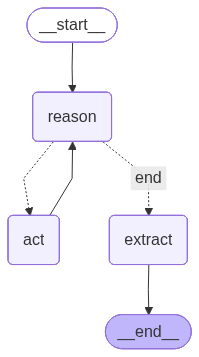
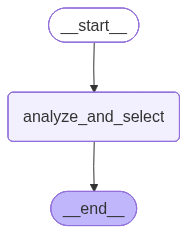
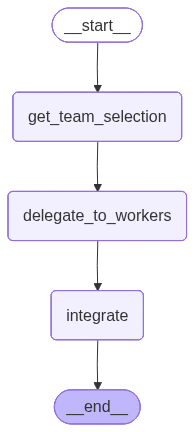

In [7]:
# 1. Capture the raw image data from graphs
raw_img1 = data_analyst_agent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)
raw_img2 = supervisor_agent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)
raw_img3 = dynamic_team_system.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

# 2. Helper to generate HTML with a title and fixed image height
def get_html_cell(binary_data, title):
    b64 = base64.b64encode(binary_data).decode()
    return f'''
    <div style="flex: 1; padding: 10px; text-align: center; border: 1px solid #eee; margin: 5px; border-radius: 8px;">
        <h4 style="margin-top: 0; color: #333; font-family: sans-serif;">{title}</h4>
        <img src="data:image/png;base64,{b64}" 
             style="height: 350px; width: 100%; object-fit: contain;" />
    </div>
    '''

# 3. Combine into a flexbox row
html_output = f'''
<div style="display: flex; flex-direction: row; justify-content: space-around; align-items: stretch;">
    {get_html_cell(raw_img1, "Worker Agent (ReAct)")}
    {get_html_cell(raw_img2, "Supervisor")}
    {get_html_cell(raw_img3, "Coordinator")}
</div>
'''

display(HTML(html_output))

## Part 5: Examples - Dynamic team composition in action
Let's see how the dynamic team pattern adapts to different task complexities. We'll run two examples:
1. **Simple task:** Should select a small team (1-2 workers)
2. **Complex task:** Should select a larger team (4-5 workers)

Observe how the supervisor autonomously makes different team selections based on its reasoning about each task.

### Example 1: Simple analytical task (small team expected)

In [8]:
# Example 1: Simple analytical task - should need fewer workers
user_request_1 = "Create a dashboard showing our monthly revenue trends and top product categories."

initial_state_1 = CoordinatorState(
    messages=[HumanMessage(content=user_request_1)],
    user_request=user_request_1,
    selected_workers=[],
    supervisor_reasoning="",
    worker_outputs={},
    final_deliverable=""
)

print("=" * 70)
print("EXAMPLE 1: SIMPLE ANALYTICAL TASK")
print("=" * 70)
print(f"\nUser request: {user_request_1}\n")
print("Expected team size: Small (2-3 workers)")
print("Expected workers: data_analyst, visualization_expert")
print("\n" + "=" * 70 + "\n")

result_1 = dynamic_team_system.invoke(initial_state_1)

# Display results
print("=" * 70)
print("SUPERVISOR'S TEAM SELECTION (Autonomous reasoning)")
print("=" * 70)
print(f"Reasoning: {result_1['supervisor_reasoning']}")
print(f"\nSelected workers ({len(result_1['selected_workers'])}): {', '.join(result_1['selected_workers'])}")
print()

print("=" * 70)
print("WORKER OUTPUTS (Only selected workers ran)")
print("=" * 70)
for worker_type, output in result_1["worker_outputs"].items():
    print(f"\n--- {worker_type.replace('_', ' ').title()} ---")
    print(output[:300] + "..." if len(output) > 300 else output)
print()

print("=" * 70)
print("FINAL INTEGRATED DELIVERABLE")
print("=" * 70)
print(result_1["final_deliverable"])
print("=" * 70)

EXAMPLE 1: SIMPLE ANALYTICAL TASK

User request: Create a dashboard showing our monthly revenue trends and top product categories.

Expected team size: Small (2-3 workers)
Expected workers: data_analyst, visualization_expert


SUPERVISOR'S TEAM SELECTION (Autonomous reasoning)
Reasoning: To create a dashboard that displays monthly revenue trends and top product categories, we need to analyze business metrics and insights, which requires the expertise of a data analyst. Additionally, we need a visualization expert to design and implement the dashboard effectively, ensuring that the data is presented in a clear and engaging manner. Therefore, both roles are essential for this task.

Selected workers (2): data_analyst, visualization_expert

WORKER OUTPUTS (Only selected workers ran)

--- Data Analyst ---
### Dashboard Overview: Monthly Revenue Trends and Top Product Categories

#### 1. Monthly Revenue Trends
- **Objective**: Analyze the monthly revenue trends over the past year.
- **Succe

### Example 2: Complex ML pipeline task (large team expected)

In [9]:
# Example 2: Complex ML pipeline task - should need more workers
user_request_2 = "Build a complete customer churn prediction system with real-time data pipeline, ML model, and monitoring dashboard."

initial_state_2 = CoordinatorState(
    messages=[HumanMessage(content=user_request_2)],
    user_request=user_request_2,
    selected_workers=[],
    supervisor_reasoning="",
    worker_outputs={},
    final_deliverable=""
)

print("\n" + "=" * 70)
print("EXAMPLE 2: COMPLEX ML PIPELINE TASK")
print("=" * 70)
print(f"\nUser request: {user_request_2}\n")
print("Expected team size: Large (4-5 workers)")
print("Expected workers: data_engineer, data_scientist, data_analyst, visualization_expert, dba")
print("\n" + "=" * 70 + "\n")

result_2 = dynamic_team_system.invoke(initial_state_2)

# Display results
print("=" * 70)
print("SUPERVISOR'S TEAM SELECTION (Autonomous reasoning)")
print("=" * 70)
print(f"Reasoning: {result_2['supervisor_reasoning']}")
print(f"\nSelected workers ({len(result_2['selected_workers'])}): {', '.join(result_2['selected_workers'])}")
print()

print("=" * 70)
print("WORKER OUTPUTS (Only selected workers ran)")
print("=" * 70)
for worker_type, output in result_2["worker_outputs"].items():
    print(f"\n--- {worker_type.replace('_', ' ').title()} ---")
    print(output[:300] + "..." if len(output) > 300 else output)
print()

print("=" * 70)
print("FINAL INTEGRATED DELIVERABLE")
print("=" * 70)
print(result_2["final_deliverable"])
print("=" * 70)


EXAMPLE 2: COMPLEX ML PIPELINE TASK

User request: Build a complete customer churn prediction system with real-time data pipeline, ML model, and monitoring dashboard.

Expected team size: Large (4-5 workers)
Expected workers: data_engineer, data_scientist, data_analyst, visualization_expert, dba


SUPERVISOR'S TEAM SELECTION (Autonomous reasoning)
Reasoning: This task requires a comprehensive approach to build a customer churn prediction system. The components involved include:

Selected workers (5): data_engineer, data_scientist, dba, data_analyst, visualization_expert

WORKER OUTPUTS (Only selected workers ran)

--- Data Engineer ---
### Monitoring Dashboard Design
The monitoring dashboard for the customer churn prediction system is designed as follows:

- **Architecture**: Event-driven architecture
- **Data Sources**: 
  - Customer churn predictions
  - Data quality metrics
  - ETL pipeline latency
- **Extraction**: Use webhook...

--- Data Scientist ---
### Machine Learning Soluti

In these executions, we see dynamic team composition in action:

**Example 1 (Simple dashboard task):**
- Supervisor reasoned that only data_analyst and visualization_expert were needed.
- System efficiently used 2 workers instead of all 5.
- Each worker ran its own ReAct loop, calling domain-specific tools.
- Coordinator integrated outputs from only the participating workers.

**Example 2 (Complex ML pipeline task):**
- Supervisor reasoned that this complex task needed all specialists.
- System allocated a larger team (5 workers) based on requirements.
- Each worker contributed their specialized expertise through autonomous reasoning.
- Coordinator integrated a comprehensive solution from all participants.

This demonstrates true agentic behavior: the supervisor analyzes each task independently and makes different team composition decisions based on its reasoning about requirements, not hardcoded rules.

### When to use hierarchical dynamic teams:

**Use this pattern when:**
- Task complexity varies significantly (simple reports vs. complex ML pipelines).
- Resource efficiency matters (don't want to run 5 agents for every task).
- Requirements cannot be predetermined (need flexible team composition).
- We want the system to adapt to different project types automatically.

**Don't use this pattern when:**
- All tasks need the same team (no variation in complexity).
- Team composition is well-defined and fixed (use hierarchical multi-tier instead).
- Single-agent solutions are sufficient (avoid unnecessary complexity).
- We need deterministic team selection (use workflow-based routing).

### Comparison with other hierarchical patterns:
- **vs. Hierarchical multi-tier:** Multi-tier has fixed team structure. Dynamic teams adapts composition per task.
- **vs. Hierarchical sequential:** Sequential pattern executes workers in order. Dynamic teams selects which workers run at all.
- **vs. Debate pattern:** Debate runs all agents and synthesizes their outputs. Dynamic teams runs only needed agents.

The hierarchical dynamic teams pattern provides the right balance of structure (hierarchical coordination) and flexibility (adaptive team composition) for systems serving diverse workloads.